In [1]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Create folder for charts
chart_dir = "movie_analytics_outputs/charts"
os.makedirs(chart_dir, exist_ok=True)

print("Chart folder ready:", chart_dir)

Chart folder ready: movie_analytics_outputs/charts


In [6]:
# ============================================
# MOVIE ANALYTICS - PREPARE DATA FOR VISUALIZATION
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import os
import warnings

warnings.filterwarnings("ignore")

# --------------------------------------------
# 1. Load datasets
# --------------------------------------------

movies = pd.read_csv("C:/Users/Varsha/Downloads/tmdb_5000_movies.csv/tmdb_5000_movies.csv")
credits = pd.read_csv("C:/Users/Varsha/Downloads/tmdb_5000_credits.csv/tmdb_5000_credits.csv")

print("Movies dataset:", movies.shape)
print("Credits dataset:", credits.shape)


# --------------------------------------------
# 2. Merge Movies + Credits
# --------------------------------------------

df = movies.merge(
    credits,
    left_on="id",
    right_on="movie_id",
    how="left"
)

# Remove duplicate ID column
df.drop(columns=["movie_id"], inplace=True)

# Rename title column
if "title_x" in df.columns:
    df.rename(columns={"title_x": "title"}, inplace=True)

if "title_y" in df.columns:
    df.drop(columns=["title_y"], inplace=True)

# Remove duplicate movies
df.drop_duplicates(subset=["id"], inplace=True)


# --------------------------------------------
# 3. Convert release date and create year
# --------------------------------------------

df["release_date"] = pd.to_datetime(
    df["release_date"],
    errors="coerce"
)

df["year"] = df["release_date"].dt.year


# --------------------------------------------
# 4. Convert numerical columns
# --------------------------------------------

numeric_columns = [
    "budget",
    "revenue",
    "runtime",
    "popularity",
    "vote_average",
    "vote_count"
]

for column in numeric_columns:
    df[column] = pd.to_numeric(
        df[column],
        errors="coerce"
    )


# --------------------------------------------
# 5. Handle invalid values
# --------------------------------------------

df.loc[df["budget"] <= 0, "budget"] = np.nan
df.loc[df["revenue"] <= 0, "revenue"] = np.nan

df.loc[
    (df["vote_average"] < 0) |
    (df["vote_average"] > 10),
    "vote_average"
] = np.nan


# --------------------------------------------
# 6. Fill selected missing values
# --------------------------------------------

df["runtime"] = df["runtime"].fillna(
    df["runtime"].median()
)

df["popularity"] = df["popularity"].fillna(
    df["popularity"].median()
)


# --------------------------------------------
# 7. Extract genres
# --------------------------------------------

def extract_genres(value):
    try:
        data = ast.literal_eval(value)
        return [item["name"] for item in data]
    except:
        return []


df["genre_list"] = df["genres"].apply(
    extract_genres
)


# --------------------------------------------
# 8. Create genre dataframe
# --------------------------------------------

genre_df = df.explode(
    "genre_list"
).copy()

genre_df.rename(
    columns={"genre_list": "genre"},
    inplace=True
)

genre_df = genre_df[
    genre_df["genre"].notna() &
    (genre_df["genre"] != "")
].copy()


# --------------------------------------------
# 9. Calculate Profit
# --------------------------------------------

df["profit"] = (
    df["revenue"] - df["budget"]
)


# --------------------------------------------
# 10. Calculate ROI
# --------------------------------------------

df["roi"] = np.where(
    df["budget"] > 0,
    ((df["revenue"] - df["budget"])
     / df["budget"]) * 100,
    np.nan
)


# --------------------------------------------
# 11. Rating Categories
# --------------------------------------------

df["rating_category"] = pd.cut(
    df["vote_average"],
    bins=[-np.inf, 5, 7, 8, np.inf],
    labels=[
        "Low",
        "Average",
        "Good",
        "Excellent"
    ]
)


# --------------------------------------------
# 12. Create chart folder
# --------------------------------------------

chart_dir = "movie_analytics_outputs/charts"

os.makedirs(
    chart_dir,
    exist_ok=True
)


# --------------------------------------------
# 13. Final confirmation
# --------------------------------------------

print("\n===================================")
print("DATA PREPARATION COMPLETED")
print("===================================")

print("Final dataframe shape:", df.shape)
print("Genre dataframe shape:", genre_df.shape)

print("\nRequired columns:")
print([
    "title",
    "genres",
    "year",
    "budget",
    "revenue",
    "profit",
    "roi",
    "vote_average"
])

print("\nFirst 5 movies:")
display(
    df[
        [
            "title",
            "year",
            "budget",
            "revenue",
            "profit",
            "roi",
            "vote_average"
        ]
    ].head()
)

print("\nGenre data:")
display(
    genre_df[
        ["title", "genre"]
    ].head(10)
)

print("\n✅ df is ready")
print("✅ genre_df is ready")
print("✅ chart folder is ready")

Movies dataset: (4803, 20)
Credits dataset: (4803, 4)

DATA PREPARATION COMPLETED
Final dataframe shape: (4803, 27)
Genre dataframe shape: (12160, 24)

Required columns:
['title', 'genres', 'year', 'budget', 'revenue', 'profit', 'roi', 'vote_average']

First 5 movies:


,title,year,budget,revenue,profit,roi,vote_average
0,Avatar,2009.0,237000000.0,2.787965e+09,2.550965e+09,1076.356577,7.2
1,Pirates of the Caribbean: At World's End,2007.0,300000000.0,9.610000e+08,6.610000e+08,220.333333,6.9
2,Spectre,2015.0,245000000.0,8.806746e+08,6.356746e+08,259.459024,6.3
3,The Dark Knight Rises,2012.0,250000000.0,1.084939e+09,8.349391e+08,333.975640,7.6
4,John Carter,2012.0,260000000.0,2.841391e+08,2.413910e+07,9.284269,6.1



Genre data:


,title,genre
0,Avatar,Action
0,Avatar,Adventure
0,Avatar,Fantasy
0,Avatar,Science Fiction
1,Pirates of the Caribbean: At World's End,Adventure
1,Pirates of the Caribbean: At World's End,Fantasy
1,Pirates of the Caribbean: At World's End,Action
2,Spectre,Action
2,Spectre,Adventure
2,Spectre,Crime



✅ df is ready
✅ genre_df is ready
✅ chart folder is ready


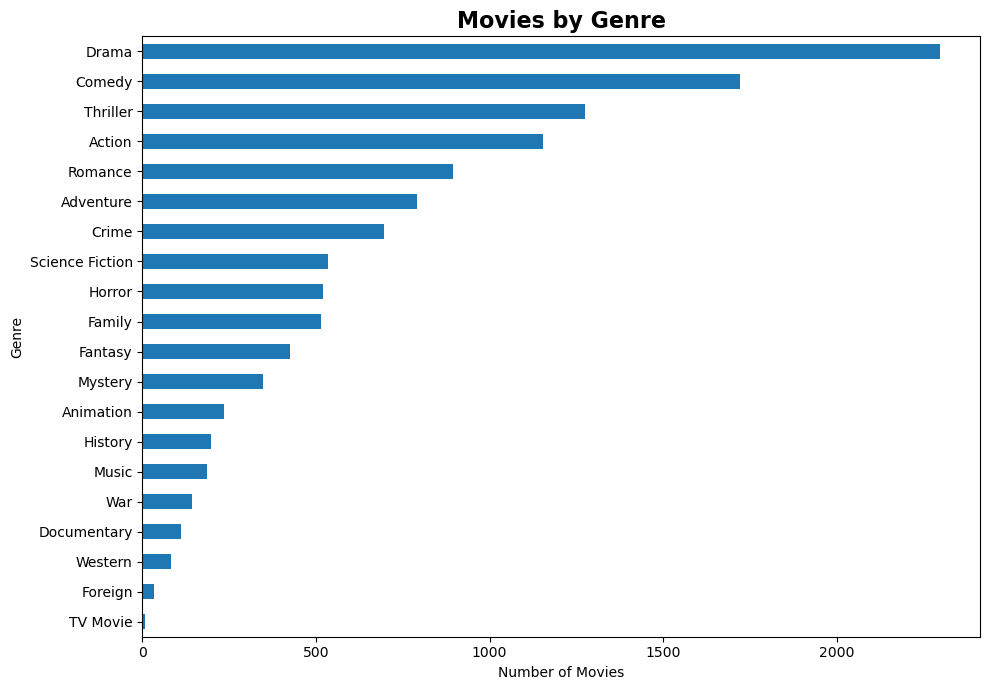

In [7]:
# 1. Movies by Genre

genre_counts = (
    genre_df["genre"]
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 7))

genre_counts.plot(kind="barh")

plt.title(
    "Movies by Genre",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Number of Movies")
plt.ylabel("Genre")

plt.tight_layout()

plt.savefig(
    f"{chart_dir}/01_movies_by_genre.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

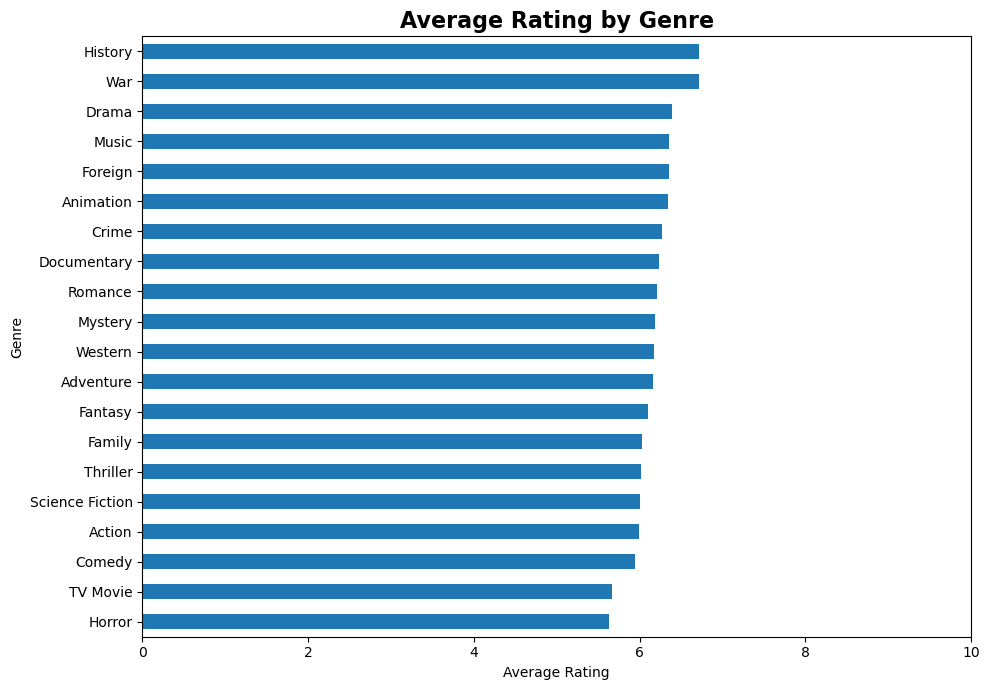

In [8]:
# ============================================
# 2. AVERAGE RATING BY GENRE
# ============================================

avg_rating_genre = (
    genre_df.groupby("genre")["vote_average"]
    .mean()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 7))

avg_rating_genre.plot(kind="barh")

plt.title(
    "Average Rating by Genre",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Average Rating")
plt.ylabel("Genre")

plt.xlim(0, 10)

plt.tight_layout()

plt.savefig(
    f"{chart_dir}/02_average_rating_by_genre.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

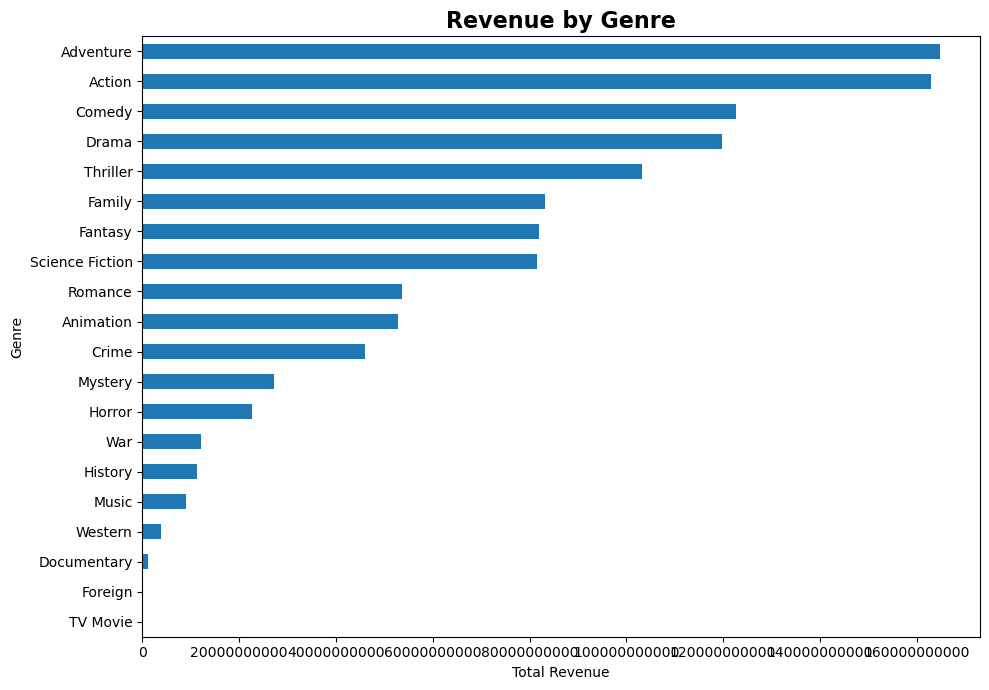

In [9]:
# ============================================
# 3. REVENUE BY GENRE
# ============================================

revenue_genre = (
    genre_df.groupby("genre")["revenue"]
    .sum()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 7))

revenue_genre.plot(kind="barh")

plt.title(
    "Revenue by Genre",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Total Revenue")
plt.ylabel("Genre")

plt.ticklabel_format(
    style="plain",
    axis="x"
)

plt.tight_layout()

plt.savefig(
    f"{chart_dir}/03_revenue_by_genre.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [11]:
# ============================================
# FIX ROI IN GENRE DATAFRAME
# ============================================

# Recalculate ROI in the main dataframe
df["roi"] = np.where(
    df["budget"] > 0,
    ((df["revenue"] - df["budget"]) / df["budget"]) * 100,
    np.nan
)

# Recreate genre dataframe so it includes ROI
genre_df = df.explode("genre_list").copy()

genre_df.rename(
    columns={"genre_list": "genre"},
    inplace=True
)

# Remove empty genres
genre_df = genre_df[
    genre_df["genre"].notna() &
    (genre_df["genre"] != "")
].copy()

print("✅ ROI added successfully!")
print("genre_df shape:", genre_df.shape)

print("\nAvailable columns:")
print(genre_df.columns.tolist())

✅ ROI added successfully!
genre_df shape: (12160, 27)

Available columns:
['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language', 'original_title', 'overview', 'popularity', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'vote_average', 'vote_count', 'cast', 'crew', 'year', 'genre', 'profit', 'roi', 'rating_category']


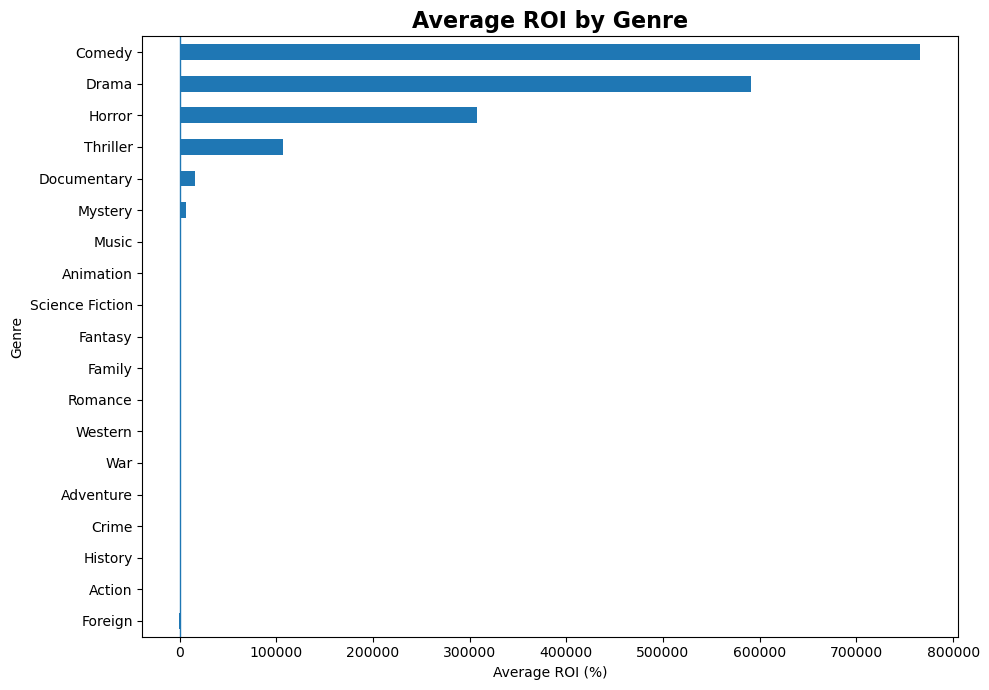

In [12]:
# ============================================
# 4. ROI BY GENRE
# ============================================

roi_genre = (
    genre_df
    .dropna(subset=["roi"])
    .groupby("genre")["roi"]
    .mean()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 7))

roi_genre.plot(kind="barh")

plt.title(
    "Average ROI by Genre",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Average ROI (%)")
plt.ylabel("Genre")

plt.axvline(
    x=0,
    linewidth=1
)

plt.tight_layout()

plt.savefig(
    f"{chart_dir}/04_average_roi_by_genre.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

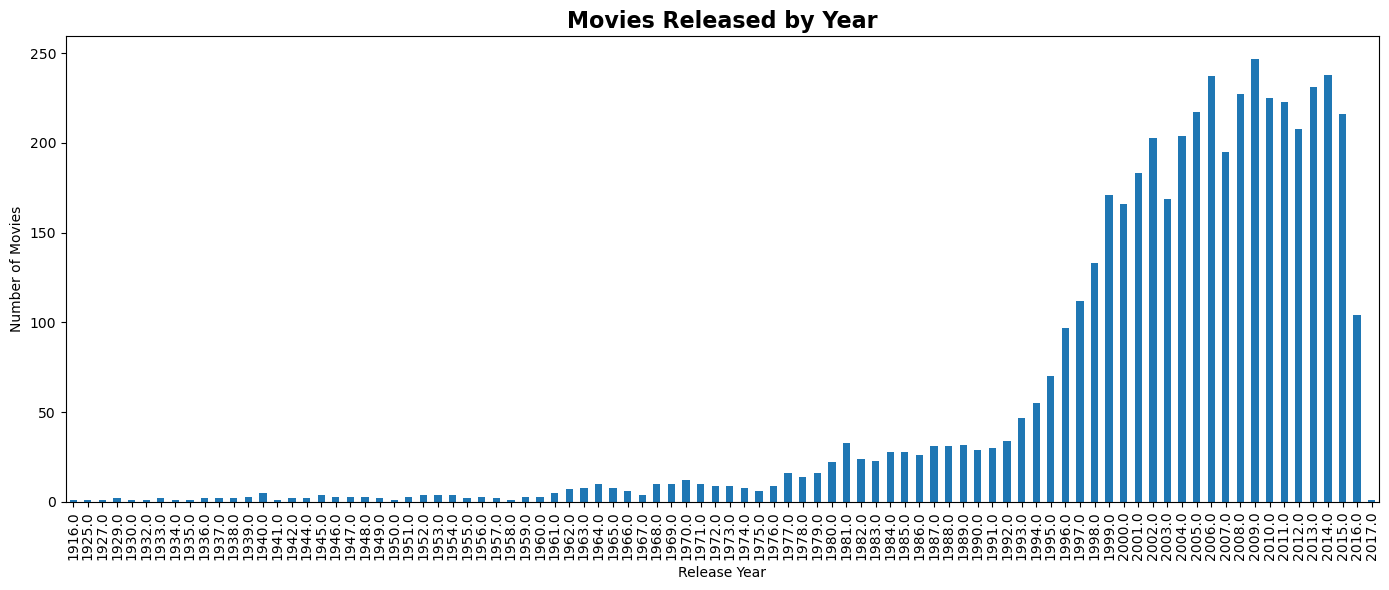

In [13]:
# ============================================
# 5. MOVIES RELEASED BY YEAR
# ============================================

movies_by_year = (
    df.dropna(subset=["year"])
    .groupby("year")["id"]
    .nunique()
)

plt.figure(figsize=(14, 6))

movies_by_year.plot(kind="bar")

plt.title(
    "Movies Released by Year",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Release Year")
plt.ylabel("Number of Movies")

plt.xticks(rotation=90)

plt.tight_layout()

plt.savefig(
    f"{chart_dir}/05_movies_released_by_year.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

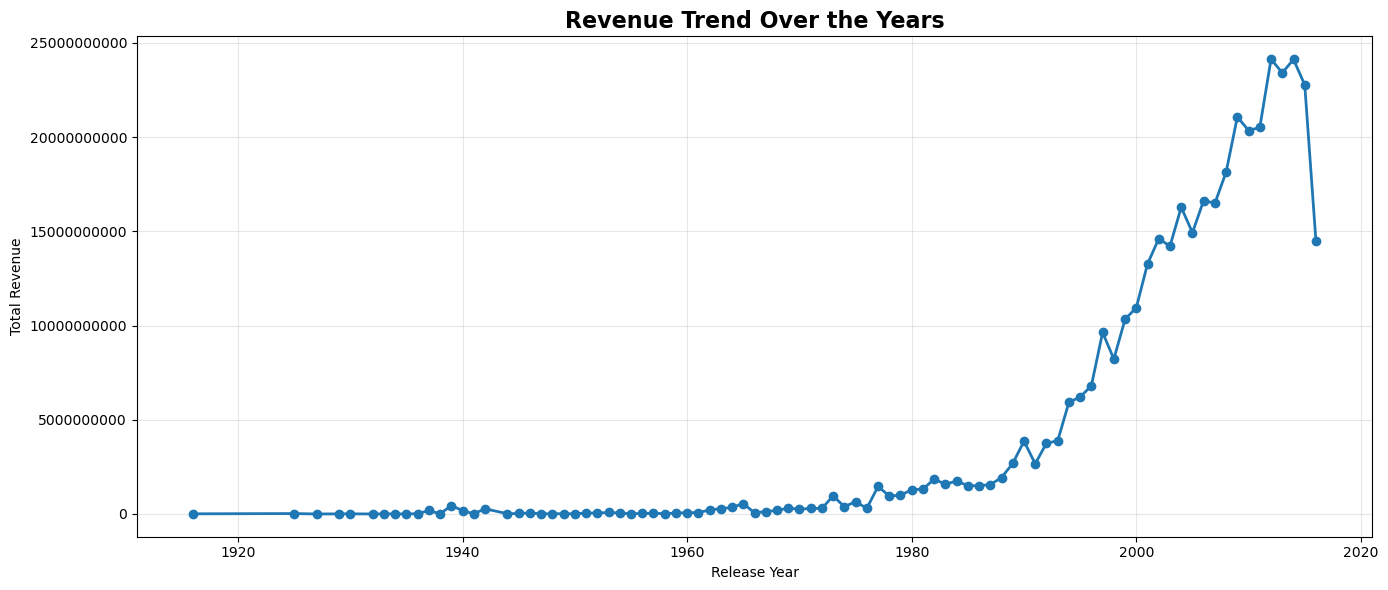

In [14]:
# ============================================
# 6. REVENUE TREND
# ============================================

revenue_by_year = (
    df.dropna(subset=["year", "revenue"])
    .groupby("year")["revenue"]
    .sum()
    .sort_index()
)

plt.figure(figsize=(14, 6))

plt.plot(
    revenue_by_year.index,
    revenue_by_year.values,
    marker="o",
    linewidth=2
)

plt.title(
    "Revenue Trend Over the Years",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Release Year")
plt.ylabel("Total Revenue")

plt.ticklabel_format(
    style="plain",
    axis="y"
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    f"{chart_dir}/06_revenue_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

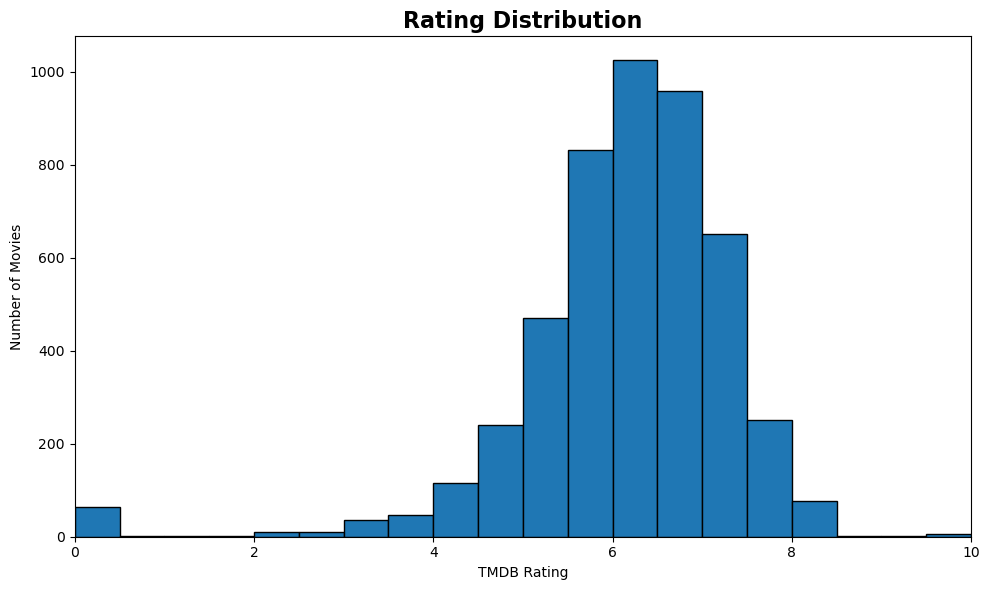

In [15]:
# ============================================
# 7. RATING DISTRIBUTION
# ============================================

rating_data = df["vote_average"].dropna()

plt.figure(figsize=(10, 6))

plt.hist(
    rating_data,
    bins=20,
    edgecolor="black"
)

plt.title(
    "Rating Distribution",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("TMDB Rating")
plt.ylabel("Number of Movies")

plt.xlim(0, 10)

plt.tight_layout()

plt.savefig(
    f"{chart_dir}/07_rating_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

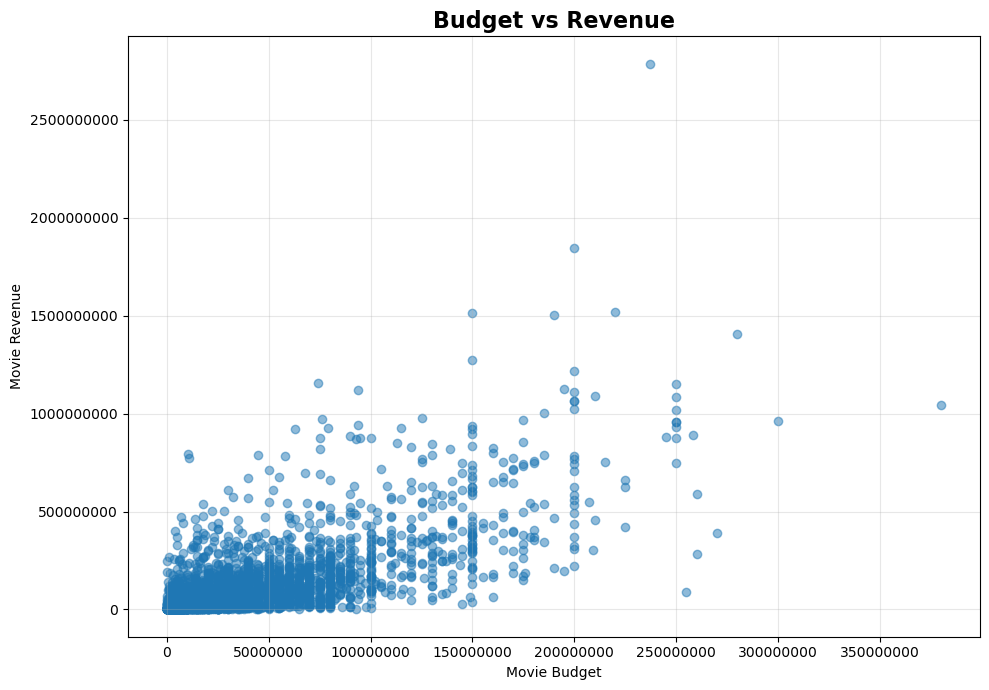

In [16]:
# ============================================
# 8. BUDGET VS REVENUE
# ============================================

budget_revenue = df[
    (df["budget"] > 0) &
    (df["revenue"] > 0)
].copy()

plt.figure(figsize=(10, 7))

plt.scatter(
    budget_revenue["budget"],
    budget_revenue["revenue"],
    alpha=0.5
)

plt.title(
    "Budget vs Revenue",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Movie Budget")
plt.ylabel("Movie Revenue")

plt.ticklabel_format(
    style="plain",
    axis="both"
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    f"{chart_dir}/08_budget_vs_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

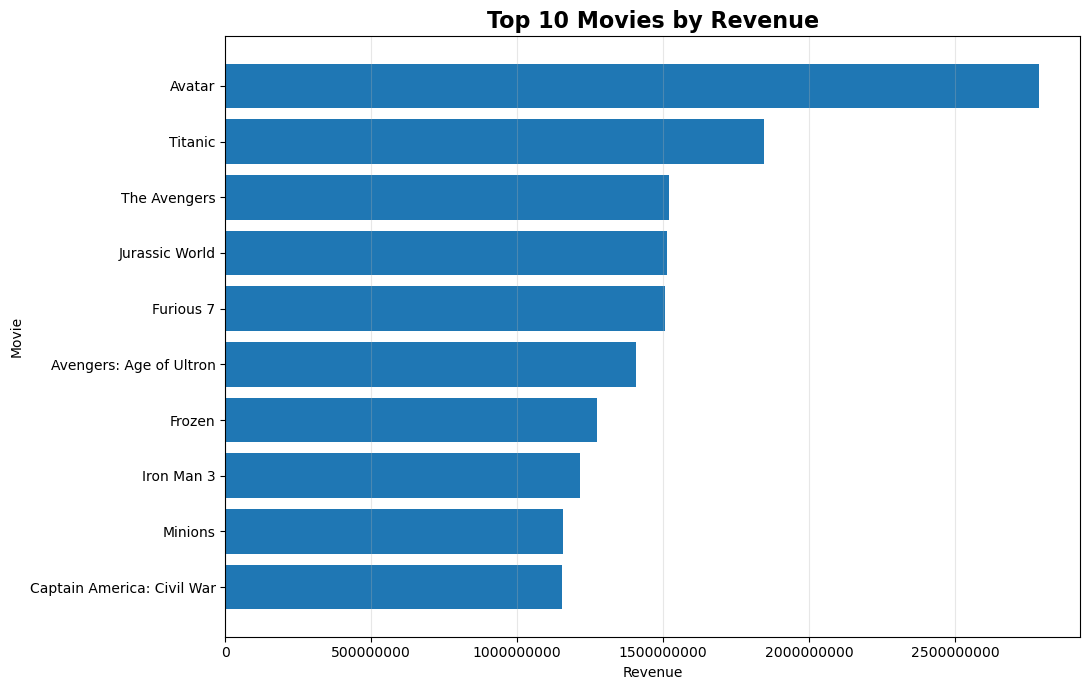

In [17]:
# Top 10 Movies by Revenue

top_revenue = (
    df[df["revenue"] > 0]
    .sort_values("revenue", ascending=False)
    .head(10)
    .sort_values("revenue", ascending=True)
)

plt.figure(figsize=(11, 7))

plt.barh(
    top_revenue["title"],
    top_revenue["revenue"]
)

plt.title("Top 10 Movies by Revenue", fontsize=16, fontweight="bold")
plt.xlabel("Revenue")
plt.ylabel("Movie")

plt.ticklabel_format(style="plain", axis="x")
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

plt.savefig(
    f"{chart_dir}/09_top_10_movies_by_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

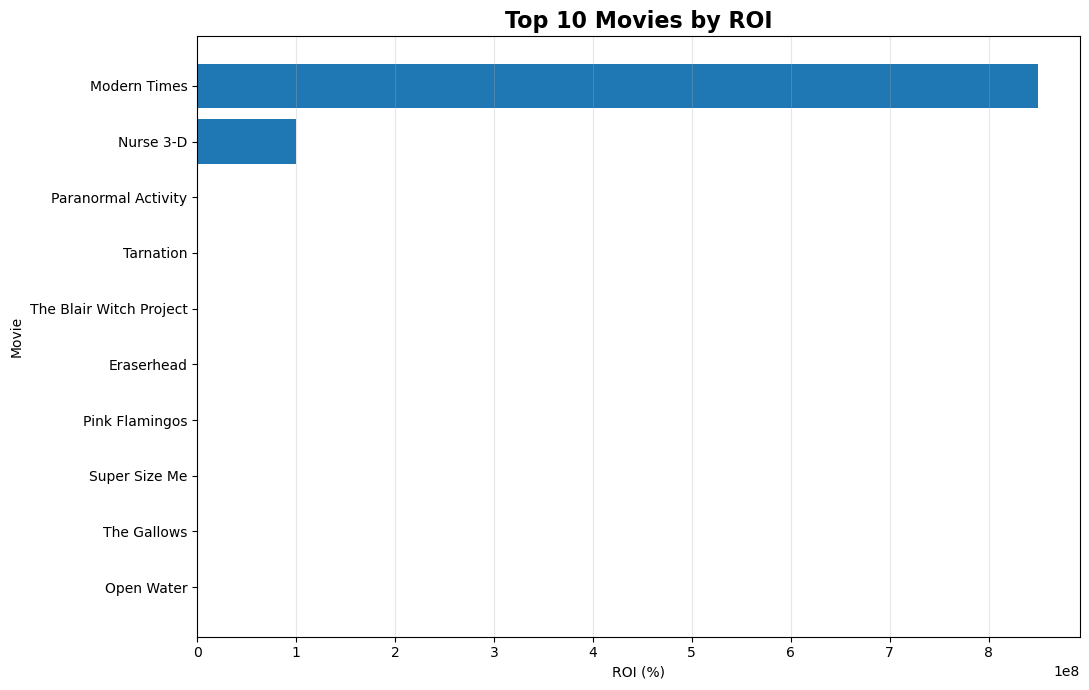

In [18]:
# Top 10 Movies by ROI

top_roi = (
    df[df["roi"].notna()]
    .sort_values("roi", ascending=False)
    .head(10)
    .sort_values("roi", ascending=True)
)

plt.figure(figsize=(11, 7))

plt.barh(
    top_roi["title"],
    top_roi["roi"]
)

plt.title("Top 10 Movies by ROI", fontsize=16, fontweight="bold")
plt.xlabel("ROI (%)")
plt.ylabel("Movie")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

plt.savefig(
    f"{chart_dir}/10_top_10_movies_by_roi.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

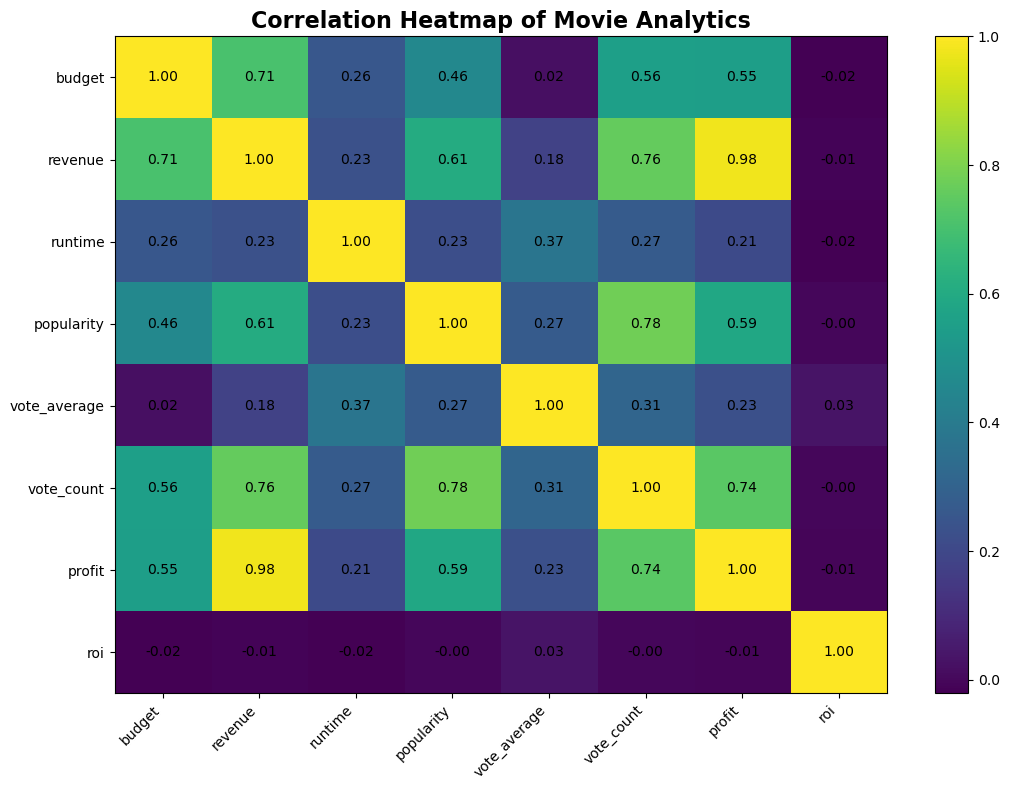

In [19]:
# Correlation Heatmap

correlation_columns = [
    "budget",
    "revenue",
    "runtime",
    "popularity",
    "vote_average",
    "vote_count",
    "profit",
    "roi"
]

corr_matrix = df[correlation_columns].corr()

plt.figure(figsize=(11, 8))

plt.imshow(corr_matrix, aspect="auto")
plt.colorbar()

plt.xticks(
    range(len(correlation_columns)),
    correlation_columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_columns)),
    correlation_columns
)

plt.title("Correlation Heatmap of Movie Analytics", fontsize=16, fontweight="bold")

# Display correlation values
for i in range(len(correlation_columns)):
    for j in range(len(correlation_columns)):
        plt.text(
            j,
            i,
            f"{corr_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.tight_layout()

plt.savefig(
    f"{chart_dir}/11_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [20]:
# ==========================================
# EXPORT DATA FOR EXCEL & POWER BI
# ==========================================

import os

# Create output folder
output_dir = "movie_analytics_outputs"
os.makedirs(output_dir, exist_ok=True)

# ------------------------------------------
# 1. Main Movie Analytics Dataset
# ------------------------------------------

powerbi_df = df.copy()

# Remove complex/list columns that Power BI doesn't need
columns_to_remove = [
    "genres",
    "keywords",
    "production_companies",
    "production_countries",
    "spoken_languages",
    "cast",
    "crew",
    "genre_list"
]

powerbi_df = powerbi_df.drop(
    columns=[col for col in columns_to_remove if col in powerbi_df.columns],
    errors="ignore"
)

powerbi_path = f"{output_dir}/movie_analytics_powerbi.csv"

powerbi_df.to_csv(
    powerbi_path,
    index=False
)

# ------------------------------------------
# 2. Genre Analysis Dataset
# ------------------------------------------

genre_powerbi = genre_df.copy()

genre_powerbi_path = f"{output_dir}/movie_genre_analysis.csv"

genre_powerbi.to_csv(
    genre_powerbi_path,
    index=False
)

# ------------------------------------------
# 3. Excel Workbook
# ------------------------------------------

excel_path = f"{output_dir}/movie_analytics.xlsx"

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:

    powerbi_df.to_excel(
        writer,
        sheet_name="Movie Analytics",
        index=False
    )

    genre_powerbi.to_excel(
        writer,
        sheet_name="Genre Analysis",
        index=False
    )

    # Top 10 Revenue
    top_revenue.to_excel(
        writer,
        sheet_name="Top Revenue",
        index=False
    )

    # Top 10 ROI
    top_roi.to_excel(
        writer,
        sheet_name="Top ROI",
        index=False
    )

print("✅ Export completed successfully!")
print()
print("📁 Output folder:", output_dir)
print()
print("Files created:")
print("1. movie_analytics_powerbi.csv")
print("2. movie_genre_analysis.csv")
print("3. movie_analytics.xlsx")

✅ Export completed successfully!

📁 Output folder: movie_analytics_outputs

Files created:
1. movie_analytics_powerbi.csv
2. movie_genre_analysis.csv
3. movie_analytics.xlsx


In [21]:
# Create Profit column

df["profit"] = df["revenue"] - df["budget"]

# Recreate ROI as well, to make sure both are present
df["roi"] = np.where(
    df["budget"] > 0,
    ((df["revenue"] - df["budget"]) / df["budget"]) * 100,
    np.nan
)

print("Profit and ROI columns created successfully!")
print(df[["title", "budget", "revenue", "profit", "roi"]].head())

Profit and ROI columns created successfully!
                                      title       budget       revenue  \
0                                    Avatar  237000000.0  2.787965e+09   
1  Pirates of the Caribbean: At World's End  300000000.0  9.610000e+08   
2                                   Spectre  245000000.0  8.806746e+08   
3                     The Dark Knight Rises  250000000.0  1.084939e+09   
4                               John Carter  260000000.0  2.841391e+08   

         profit          roi  
0  2.550965e+09  1076.356577  
1  6.610000e+08   220.333333  
2  6.356746e+08   259.459024  
3  8.349391e+08   333.975640  
4  2.413910e+07     9.284269  


In [22]:
# Re-export updated Power BI dataset

powerbi_df = df.copy()

columns_to_remove = [
    "genres",
    "keywords",
    "production_companies",
    "production_countries",
    "spoken_languages",
    "cast",
    "crew",
    "genre_list"
]

powerbi_df = powerbi_df.drop(
    columns=[col for col in columns_to_remove if col in powerbi_df.columns],
    errors="ignore"
)

powerbi_path = f"{output_dir}/movie_analytics_powerbi.csv"

powerbi_df.to_csv(
    powerbi_path,
    index=False
)

print("✅ Power BI CSV updated successfully!")
print("Profit present:", "profit" in powerbi_df.columns)
print("ROI present:", "roi" in powerbi_df.columns)

✅ Power BI CSV updated successfully!
Profit present: True
ROI present: True


In [23]:
import os

print("Your current Jupyter folder is:")
print(os.getcwd())

Your current Jupyter folder is:
C:\Users\Varsha


In [24]:
import os

output_dir = "movie_analytics_outputs"

print("Output folder location:")
print(os.path.abspath(output_dir))

print("\nDoes the folder exist?")
print(os.path.exists(output_dir))

Output folder location:
C:\Users\Varsha\movie_analytics_outputs

Does the folder exist?
True


In [25]:
import os

os.startfile(os.path.abspath("movie_analytics_outputs"))